
=== Checking DESIRE BEVs ===
Found 129 BEV files

--- Frame 1/129 ---
bev_00001.npy: shape = (1, 256, 256)


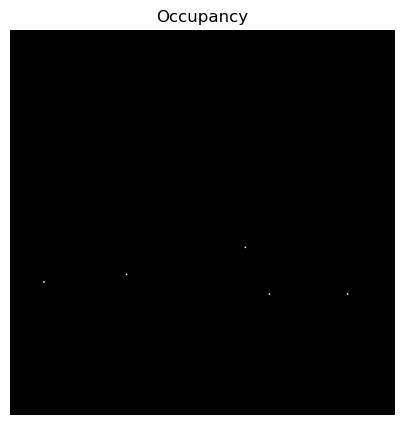


--- Frame 2/129 ---
bev_00002.npy: shape = (1, 256, 256)


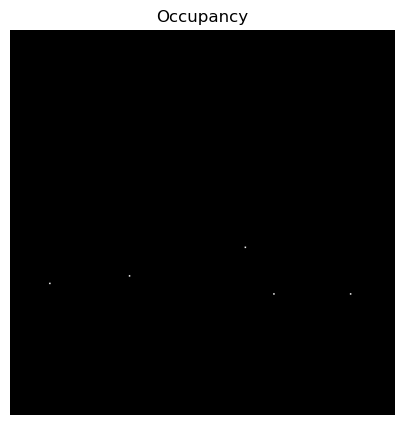


--- Frame 3/129 ---
bev_00003.npy: shape = (1, 256, 256)


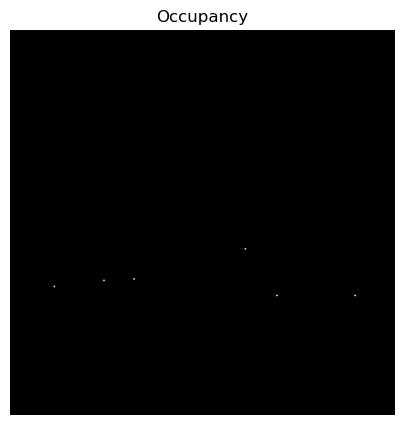


--- Frame 4/129 ---
bev_00004.npy: shape = (1, 256, 256)


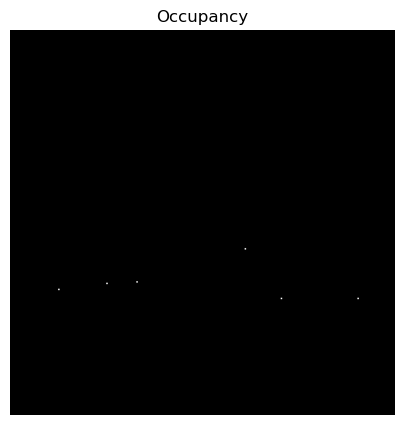


--- Frame 5/129 ---
bev_00005.npy: shape = (1, 256, 256)


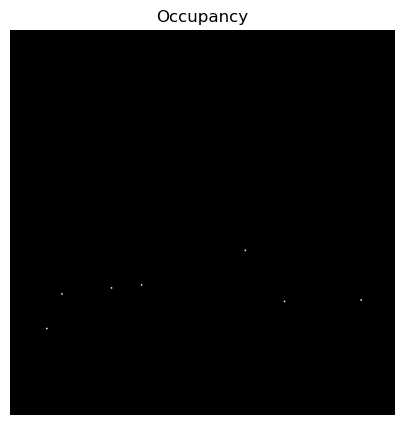


=== Checking HiVT BEVs ===
Found 129 BEV files

--- Frame 1/129 ---
bev_00001.npy: shape = (3, 256, 256)


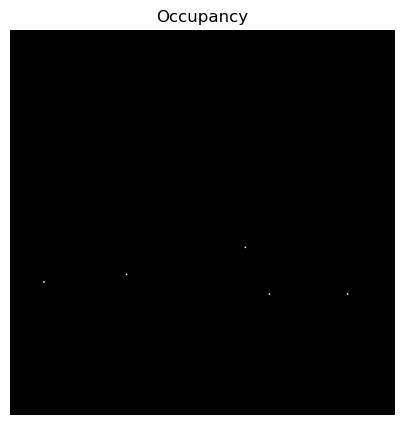

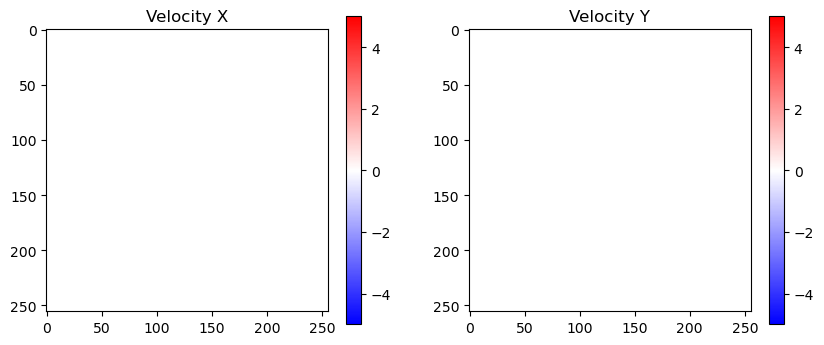


--- Frame 2/129 ---
bev_00002.npy: shape = (3, 256, 256)


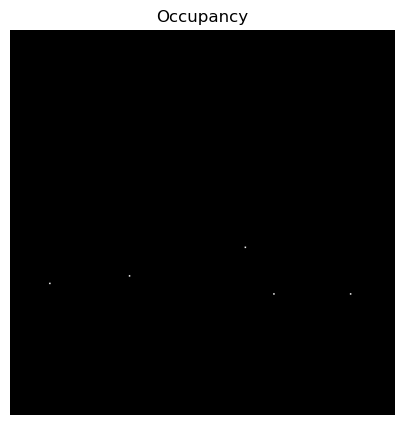

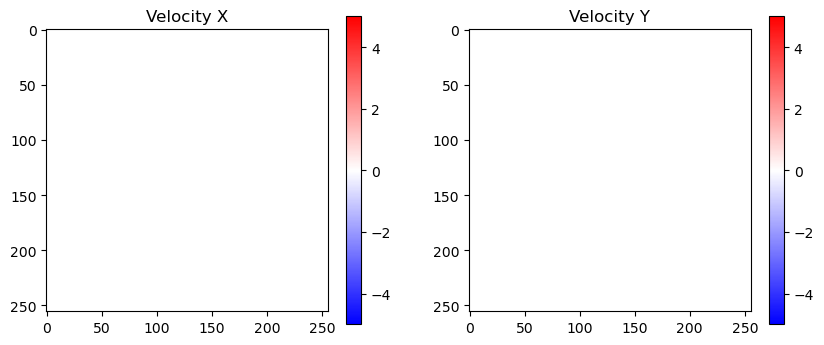


--- Frame 3/129 ---
bev_00003.npy: shape = (3, 256, 256)


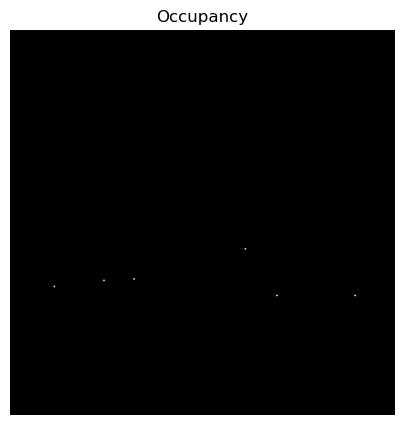

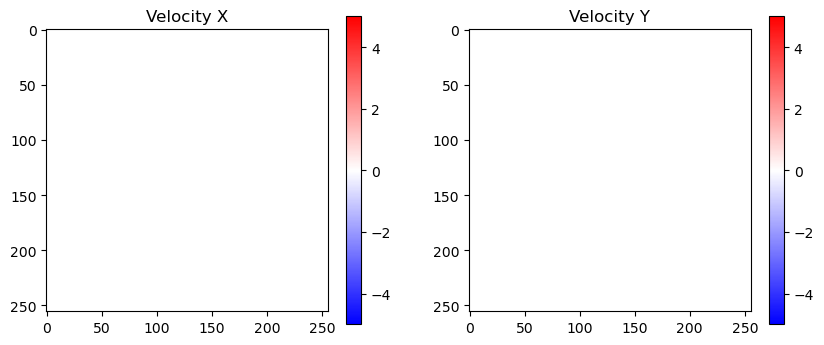


--- Frame 4/129 ---
bev_00004.npy: shape = (3, 256, 256)


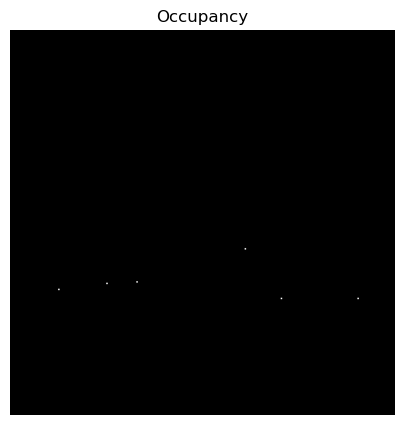

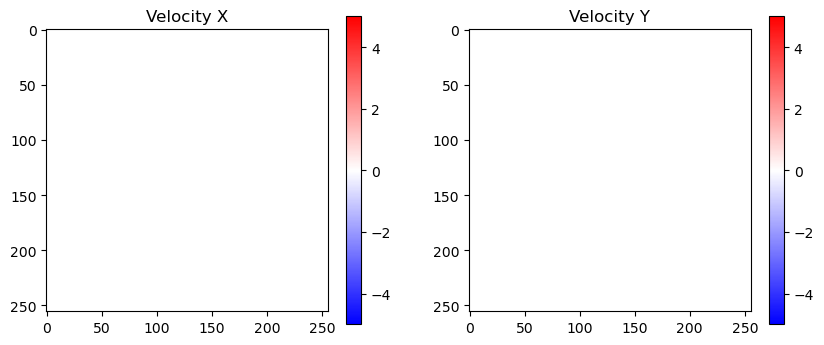


--- Frame 5/129 ---
bev_00005.npy: shape = (3, 256, 256)


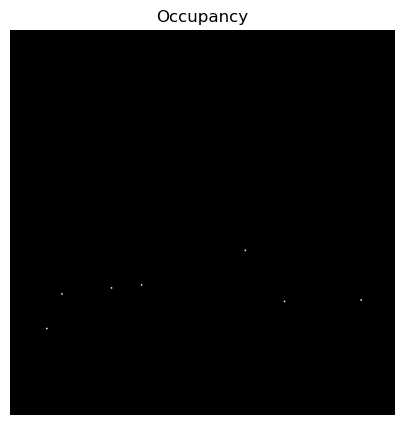

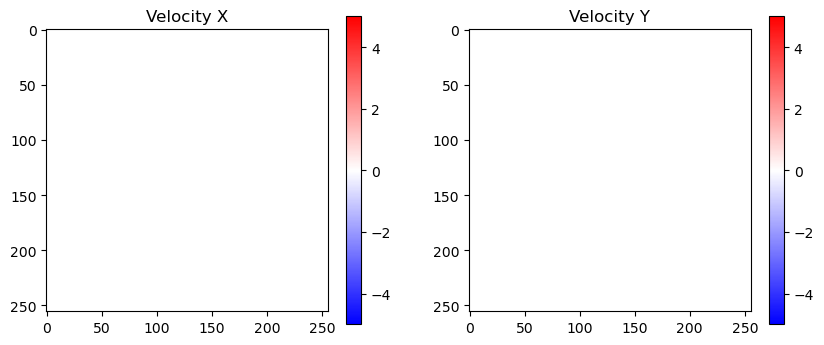

In [7]:
# ----------------------------------------
# BEV Verification Notebook for DESIRE & HiVT
# ----------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- CONFIG ----------------
bev_folders = {
    "DESIRE": Path(r"C:\Users\agon_\trajectory_prediction\data\processed\bev_desire\Video 113"),
    "HiVT": Path(r"C:\Users\agon_\trajectory_prediction\data\processed\bev_hivt\Video 113"),
}

# Max Frames to visualize per scene
max_frames = 5

# ---------------- HELPER ----------------
def visualize_bev(bev_path):
    bev = np.load(bev_path)
    C, H, W = bev.shape
    print(f"{bev_path.name}: shape = {bev.shape}")

    # -------- Occupancy --------
    plt.figure(figsize=(5,5))
    plt.imshow(bev[0], cmap='gray')
    plt.title("Occupancy")
    plt.axis('off')
    plt.show()

    # -------- Velocity --------
    if C >= 3:
        vx = bev[1]
        vy = bev[2]

        # Mask zero pixels for better visibility
        vx_masked = np.ma.masked_where(vx == 0, vx)
        vy_masked = np.ma.masked_where(vy == 0, vy)

        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.imshow(vx_masked, cmap='bwr', vmin=-5, vmax=5)
        plt.title("Velocity X")
        plt.colorbar()
        plt.subplot(1,2,2)
        plt.imshow(vy_masked, cmap='bwr', vmin=-5, vmax=5)
        plt.title("Velocity Y")
        plt.colorbar()
        plt.show()

    # -------- Semantic --------
    if C > 3:
        n_semantic = C - 3
        print(f"Semantic channels: {n_semantic}")
        for i in range(min(3, n_semantic)):
            plt.figure(figsize=(5,5))
            plt.imshow(bev[3+i], cmap='tab20')
            plt.title(f"Semantic channel {i}")
            plt.axis('off')
            plt.show()

    # -------- Composite RGB --------
    if C > 3:
        n_semantic = C - 3
        rgb = np.zeros((H, W, 3), dtype=np.float32)
        rgb[...,0] = bev[3]   # first semantic channel -> R
        if n_semantic > 1:
            rgb[...,1] = bev[4] # second semantic channel -> G
        if n_semantic > 2:
            rgb[...,2] = bev[5] # third semantic channel -> B
        plt.figure(figsize=(5,5))
        plt.imshow(rgb)
        plt.title("Composite RGB (Semantic)")
        plt.axis('off')
        plt.show()

# ---------------- PROCESS ----------------
for mode, folder in bev_folders.items():
    print(f"\n=== Checking {mode} BEVs ===")
    bev_files = sorted(folder.glob("bev_*.npy"))
    print(f"Found {len(bev_files)} BEV files")

    for i, bev_file in enumerate(bev_files[:max_frames]):
        print(f"\n--- Frame {i+1}/{len(bev_files)} ---")
        visualize_bev(bev_file)


